# Modelo para Classificação da Qualidade de Vinhos
### TechChallenge - Fase 2 - Data Analytics 2026

#### **Aluno**: Bruno Ricardo de Oliveira - Grupo: 143

***Objetivo***: Desenvolver modelos de classificação capaz de prever a qualidade de vinhos com base em variáveis físico-químicas.


#### Base de Dados a ser analisada para modelagem dos modelos

O Data Frame contém as seguintes colunas:

Input variables (based on physicochemical tests):\
1 - fixed acidity\
2 - volatile acidity\
3 - citric acid\
4 - residual sugar\
5 - chlorides\
6 - free sulfur dioxide\
7 - total sulfur dioxide\
8 - density\
9 - pH\
10 - sulphates\
11 - alcohol\
Output variable (based on sensory data):\
12 - quality (score between 0 and 10)

Em resumo, a base contém atributos físico-químicos como acidez fixa, acidez volátil, ácido cítrico, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos, álcool e a nota  quality.

#### Instalação das Bibliotecas

In [31]:
from pathlib import Path
import subprocess
import sys

# encontrando o requirements.txt
requirements_file = next(
    (parent / "requirements.txt" for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "requirements.txt").exists()),
    None,
)

if requirements_file is None:
    raise FileNotFoundError("requirements.txt não encontrado. Abra o notebook dentro do repositório clonado.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_file)])
print(f"Dependências instaladas a partir de: {requirements_file}")

Dependências instaladas a partir de: /Users/brunoricardo/Documents/Cursos/POSTECH FIAP - DATA ANALYTICS/FASE 2/TECH CHALLENGE/wine-quality-classification/requirements.txt


#### Importação das Bibliotecas para Análise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

#### Configurações Gerais

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)


#### Importando a Base de Dados

In [4]:
data_path = Path("../data/WineQT.csv")
df = pd.read_csv(data_path, sep=",")

## EDA - ANÁLISE ESPLORATÓRIA DOS DADOS

### Verificações Iniciais da Base

In [5]:
print(f"Shape da base (Quantidade de linhas, Quantidade de colunas): {df.shape}")

print("Primeiras linhas da base de dados e seus valores:")
df.head()

Shape da base (Quantidade de linhas, Quantidade de colunas): (1143, 13)
Primeiras linhas da base de dados e seus valores:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,0
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,1
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,2
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,3
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,4


In [6]:
print(f"Ultimas Linhas da base de dados e seus valores:")
df.tail()

Ultimas Linhas da base de dados e seus valores:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3000,0.5100,0.1300,2.3000,0.0760,29.0000,40.0000,0.9957,3.4200,0.7500,11.0000,6,1592
1139,6.8000,0.6200,0.0800,1.9000,0.0680,28.0000,38.0000,0.9965,3.4200,0.8200,9.5000,6,1593
1140,6.2000,0.6000,0.0800,2.0000,0.0900,32.0000,44.0000,0.9949,3.4500,0.5800,10.5000,5,1594
1141,5.9000,0.5500,0.1000,2.2000,0.0620,39.0000,51.0000,0.9951,3.5200,0.7600,11.2000,6,1595
1142,5.9000,0.6450,0.1200,2.0000,0.0750,32.0000,44.0000,0.9955,3.5700,0.7100,10.2000,5,1597


In [7]:
print("Ordem das Colunas da Base de Dados:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

Ordem das Colunas da Base de Dados:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality
13. Id


#### Tipos de Dados e Valores não Nulos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Avaliar se existem IDs Duplicados:

In [9]:
ids_duplicados = df["Id"].is_unique
print(f"Ids Duplicados na base? -> ", "Não" if ids_duplicados else "Sim")

Ids Duplicados na base? ->  Não


#### Estatística Descritiva

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0000,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143.0000,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143.0000,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143.0000,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143.0000,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143.0000,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143.0000,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143.0000,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143.0000,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143.0000,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


#### Verificando Valores Ausentes na Base

In [11]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]
print(f"Quantidade de Valores Nulos na Base de Dados: {missing_values.sum()}")


Quantidade de Valores Nulos na Base de Dados: 0


Validação visual com a Matrix missingno

<Axes: >

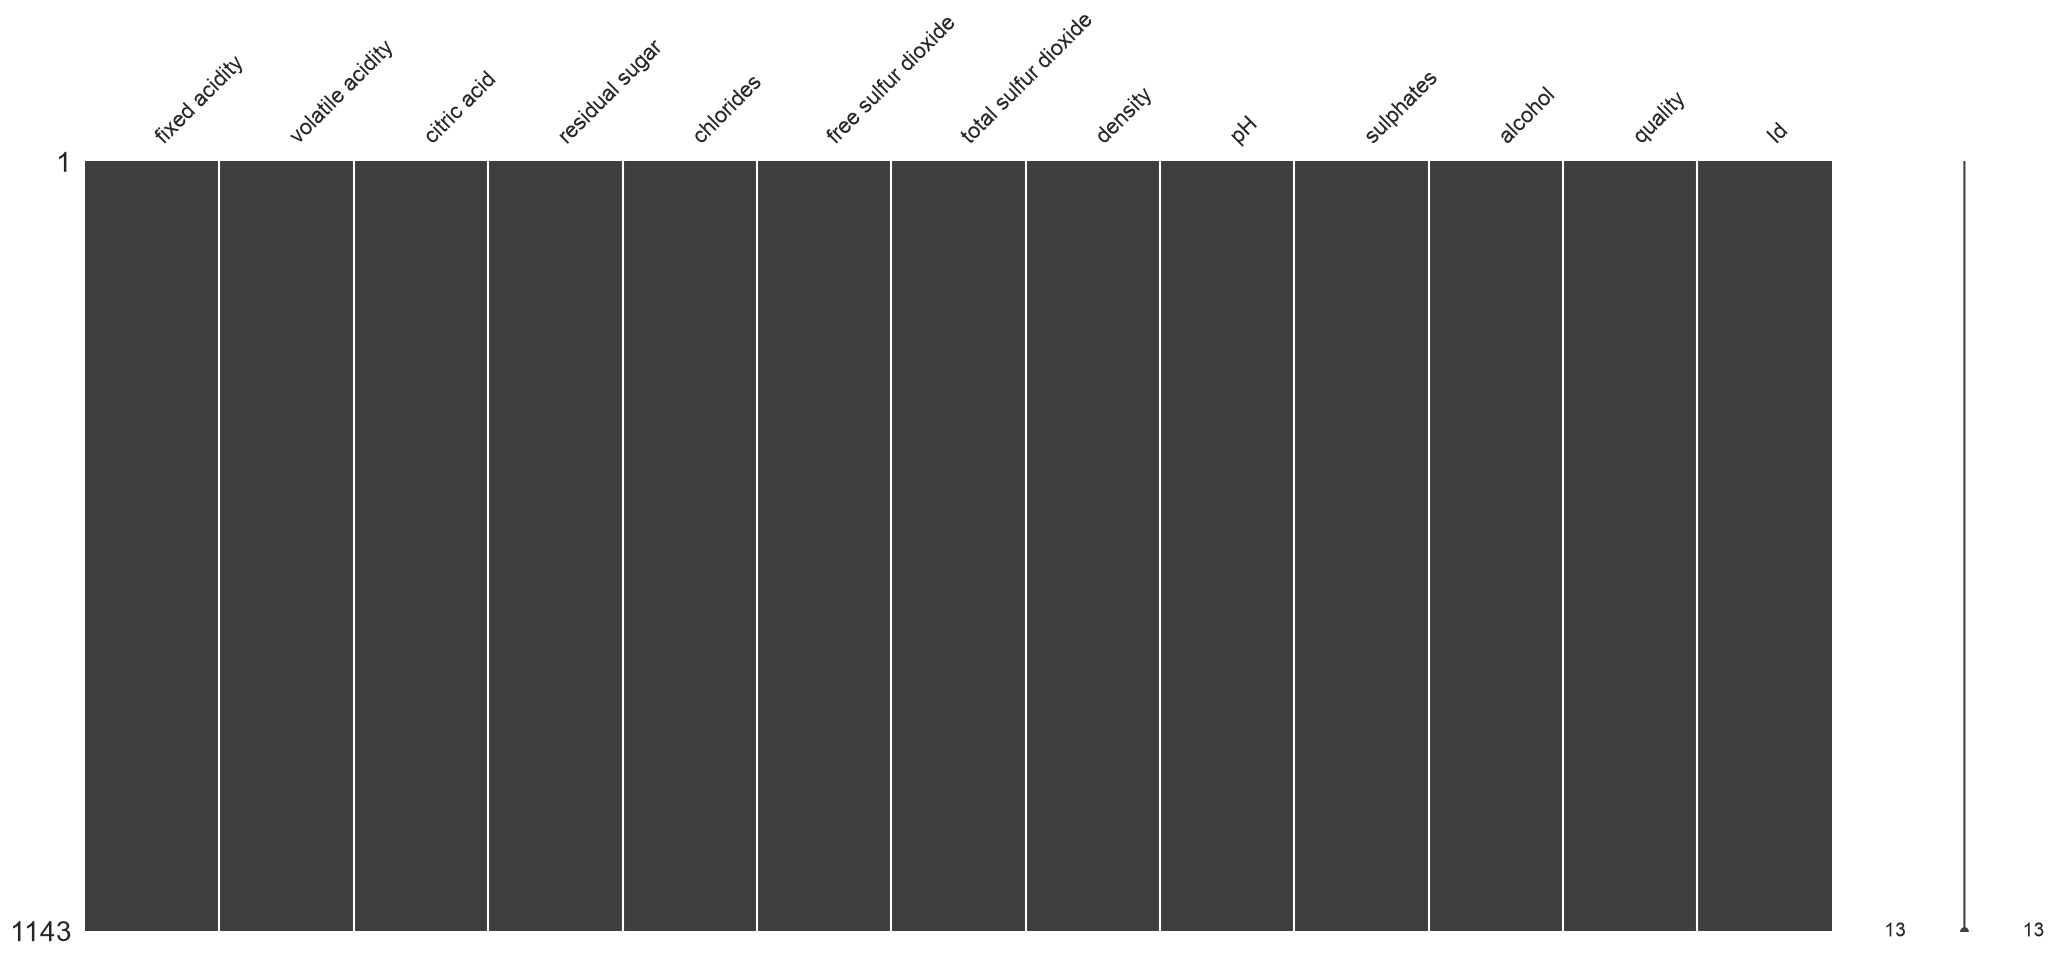

In [12]:
msno.matrix(df)

#### Verificação de Valores Duplicados

In [13]:
#### Verificação de Valores Duplicados
duplicate_values = df.duplicated().sum()
print(f"Quantidade de valores duplicados: {duplicate_values}")

Quantidade de valores duplicados: 0


#### Avaliando a Distribuição da Qualidade da Base

Distribuição da Variável `quality` na base de dados: 


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

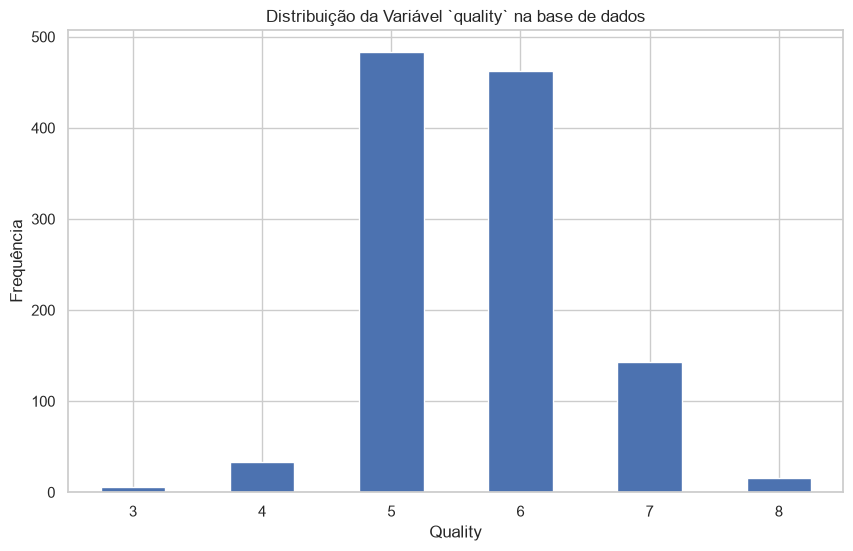

In [14]:
quality_counts = df["quality"].value_counts().sort_index()
print("Distribuição da Variável `quality` na base de dados: ")
display(quality_counts)

ax = quality_counts.plot(kind="bar")
ax.set_title("Distribuição da Variável `quality` na base de dados")
ax.set_xlabel("Quality")
ax.set_ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

#### Analisando a distribuição de cada Variável Característica e Outliers

In [31]:
def detalhe_ouliers ():
    """
    Função para detalhar os outliers da base de dados.
    Identificando outliers usando o método do IQR
    """
    features = df.drop(columns=['quality', 'Id'], errors='ignore').select_dtypes(include='number').columns

    features = df.drop(columns=['quality', 'Id'], errors='ignore').select_dtypes(include='number').columns

    resumo_outlier = []

    for col in features:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        resumo_outlier.append({
            'variavel': col,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'limite_inferior': lower_bound,
            'limite_superior': upper_bound,
            'qtd_outliers': outliers.shape[0],
            'pct_outliers': outliers.shape[0] / df.shape[0] * 100
        })

    outlier_summary_df = pd.DataFrame(resumo_outlier)

    outlier_summary_df.sort_values(
        by='qtd_outliers',
        ascending=False,
        inplace=True
    )
    return outlier_summary_df


Resumo de outliers por variável:


,variavel,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers,pct_outliers
3,residual sugar,1.900,2.600,0.700,0.850,3.650,110,9.62%
4,chlorides,0.070,0.090,0.020,0.040,0.120,77,6.74%
0,fixed acidity,7.100,9.100,2.000,4.100,12.100,44,3.85%
9,sulphates,0.550,0.730,0.180,0.280,1.000,43,3.76%
6,total sulfur dioxide,21.000,61.000,40.000,-39.000,121.000,40,3.50%
7,density,0.996,0.998,0.002,0.992,1.001,36,3.15%
8,pH,3.205,3.400,0.195,2.913,3.692,20,1.75%
5,free sulfur dioxide,7.000,21.000,14.000,-14.000,42.000,18,1.57%
1,volatile acidity,0.393,0.640,0.247,0.021,1.011,14,1.22%
10,alcohol,9.500,11.100,1.600,7.100,13.500,12,1.05%


Análise detalhada de outliers por variável:


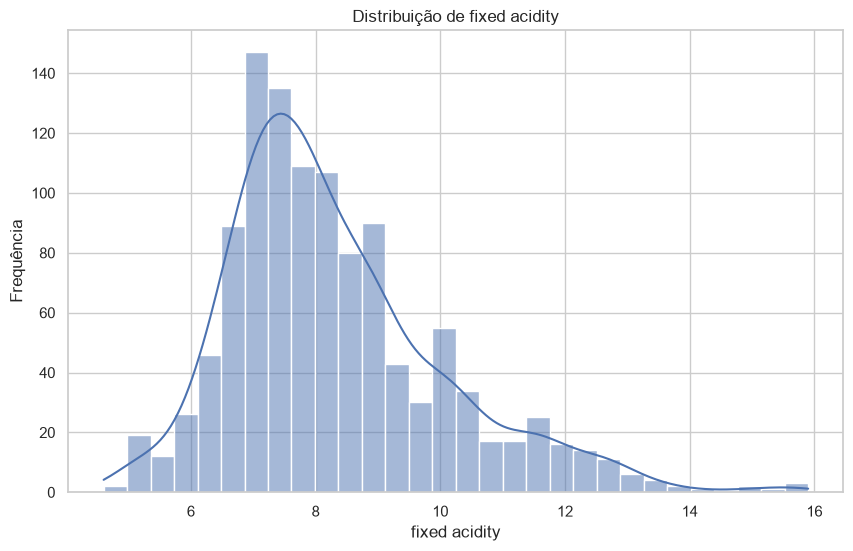

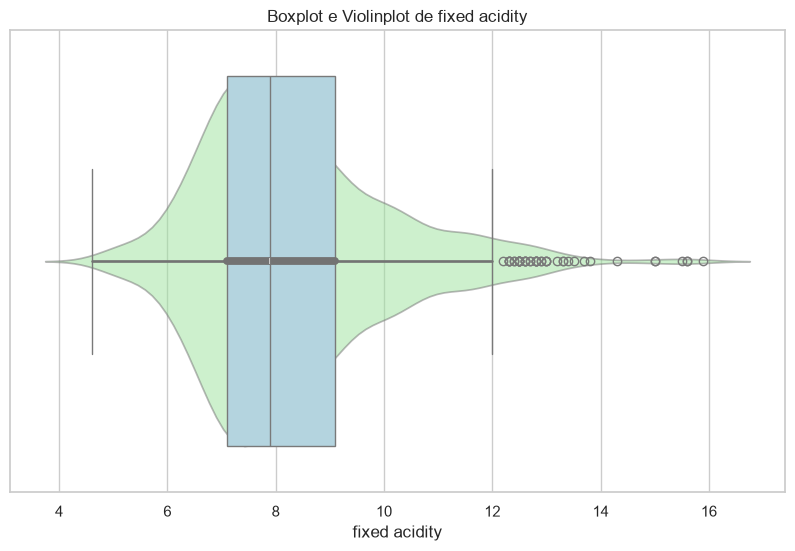

Outliers de fixed acidity: 44 registros


,Id,fixed acidity,quality
279,402,12.2000,6
306,435,12.3000,5
416,581,12.3000,5
415,580,12.3000,5
304,433,12.3000,5
425,596,12.4000,6
392,548,12.4000,6
284,409,12.5000,4
313,446,12.5000,5
334,472,12.5000,6


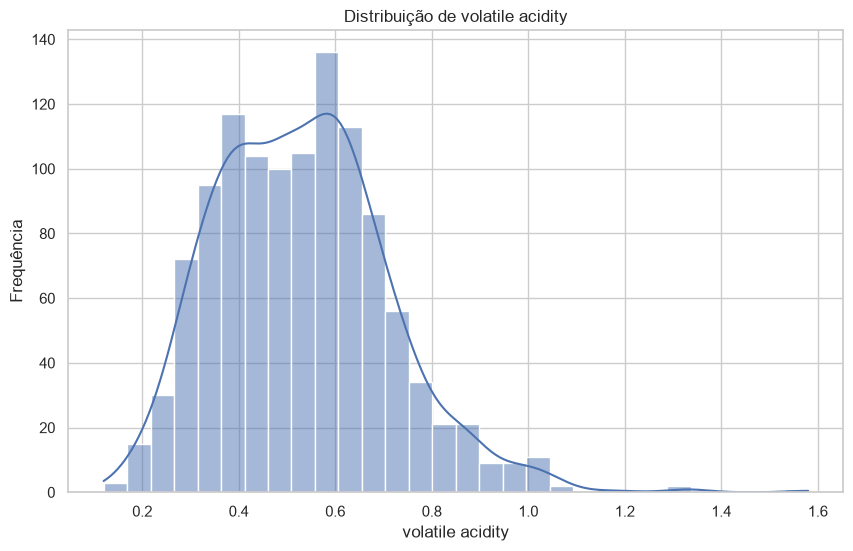

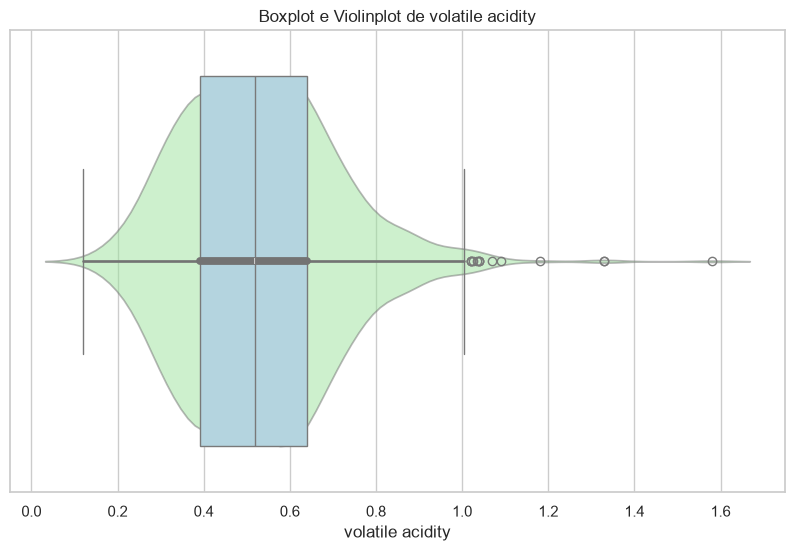

Outliers de volatile acidity: 14 registros


,Id,volatile acidity,quality
66,94,1.0200,4
497,700,1.0200,6
891,1261,1.0200,4
506,710,1.0250,5
502,705,1.0350,5
92,134,1.0400,6
396,553,1.0400,5
1044,1467,1.0400,4
83,120,1.0700,5
142,199,1.0900,4


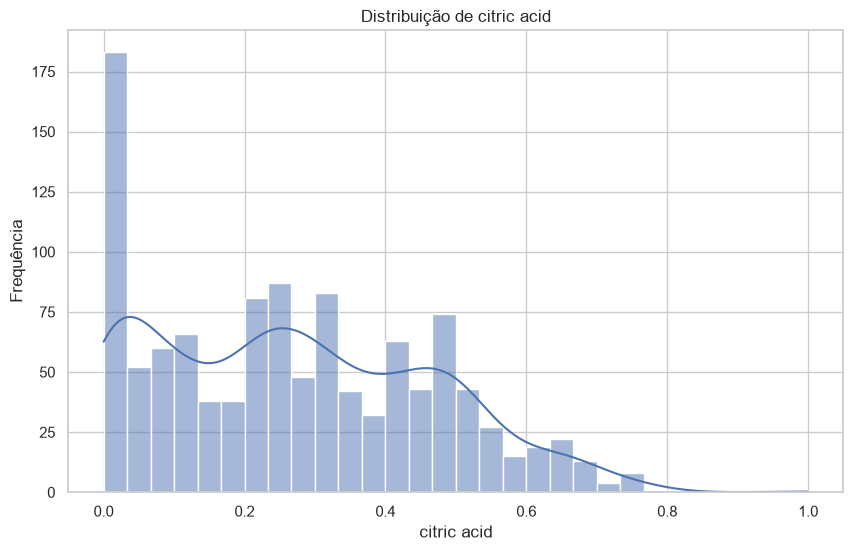

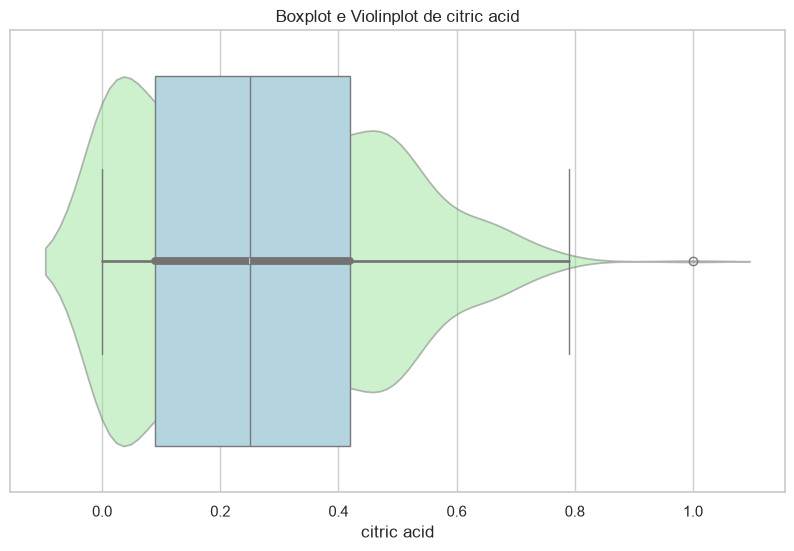

Outliers de citric acid: 1 registros


,Id,citric acid,quality
103,151,1.0000,4


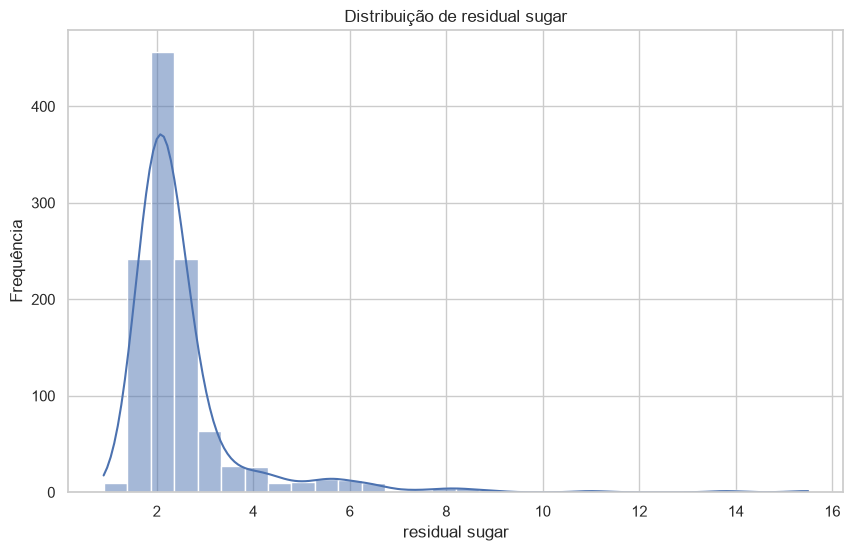

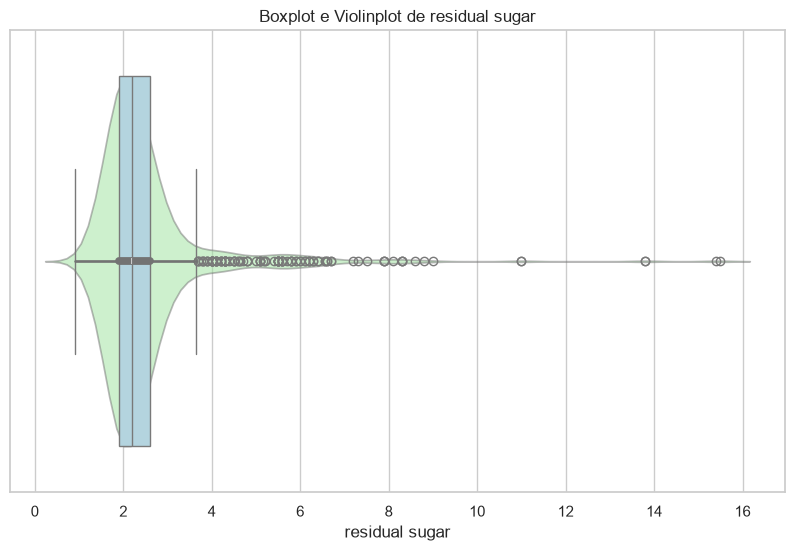

Outliers de residual sugar: 110 registros


,Id,residual sugar,quality
1106,1552,3.7000,6
311,442,3.7000,7
804,1138,3.7000,5
1048,1471,3.7500,5
643,910,3.8000,6
...,...,...,...
231,325,11.0000,6
1051,1474,13.8000,5
1053,1476,13.8000,5
1022,1434,15.4000,6


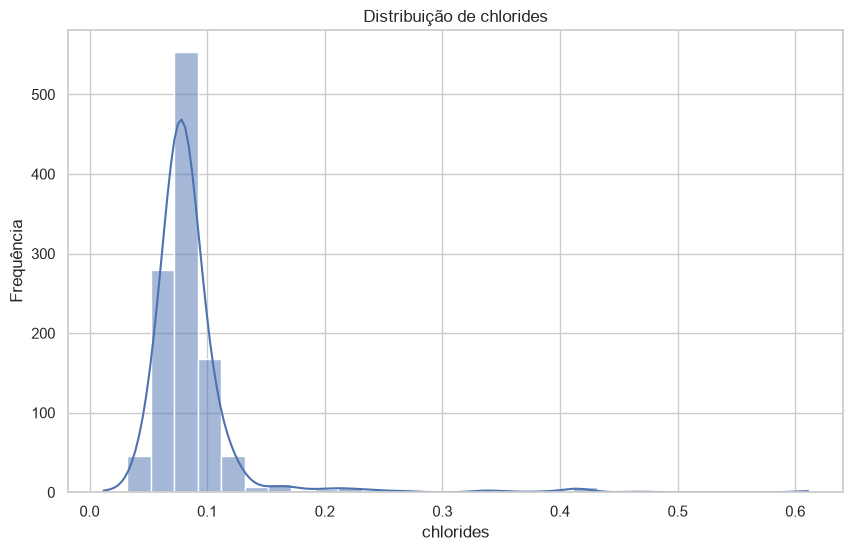

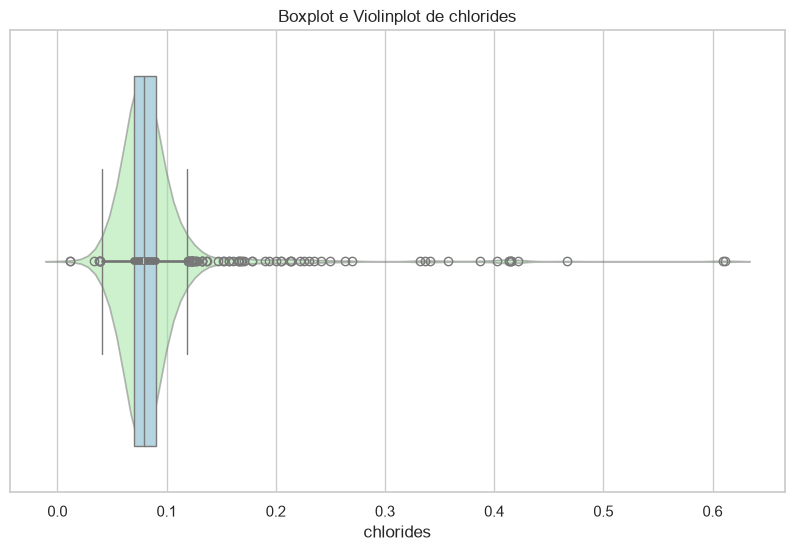

Outliers de chlorides: 77 registros


,Id,chlorides,quality
597,836,0.0120,7
598,837,0.0120,7
493,695,0.0340,6
574,797,0.0380,7
1123,1571,0.0380,6
...,...,...,...
538,754,0.4150,6
490,692,0.4220,5
75,106,0.4670,5
103,151,0.6100,4


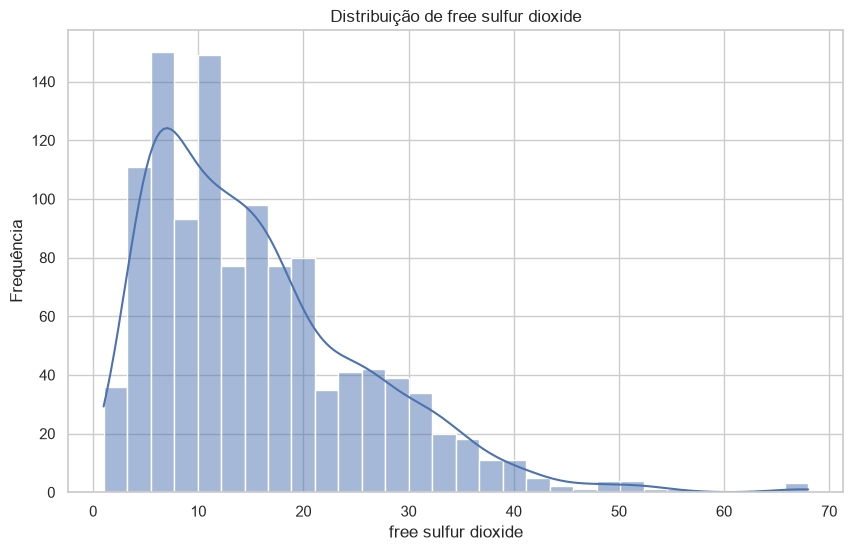

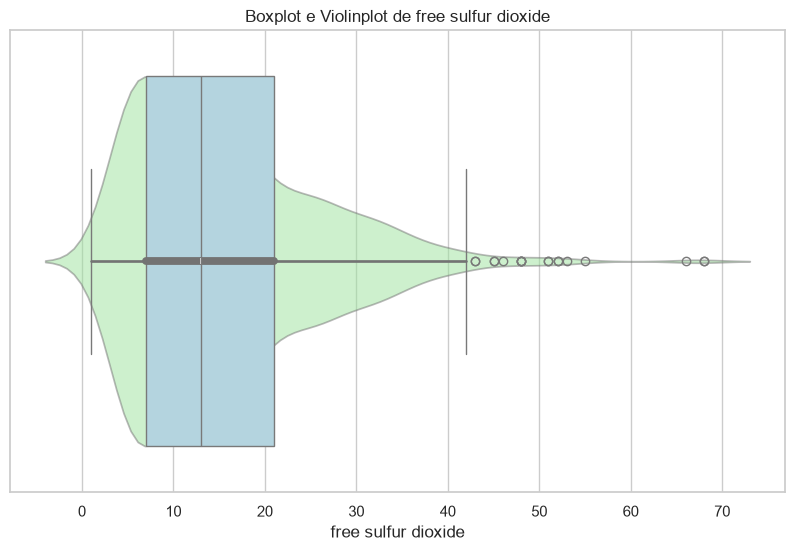

Outliers de free sulfur dioxide: 18 registros


,Id,free sulfur dioxide,quality
351,497,43.0000,5
887,1256,43.0000,5
820,1156,45.0000,7
480,678,45.0000,5
450,634,46.0000,5
1051,1474,48.0000,5
1053,1476,48.0000,5
831,1175,48.0000,6
871,1231,48.0000,5
690,982,51.0000,6


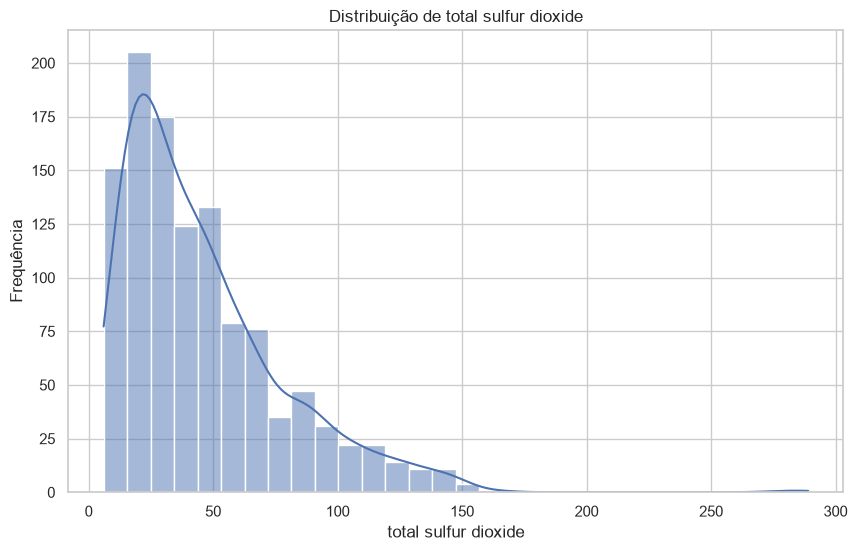

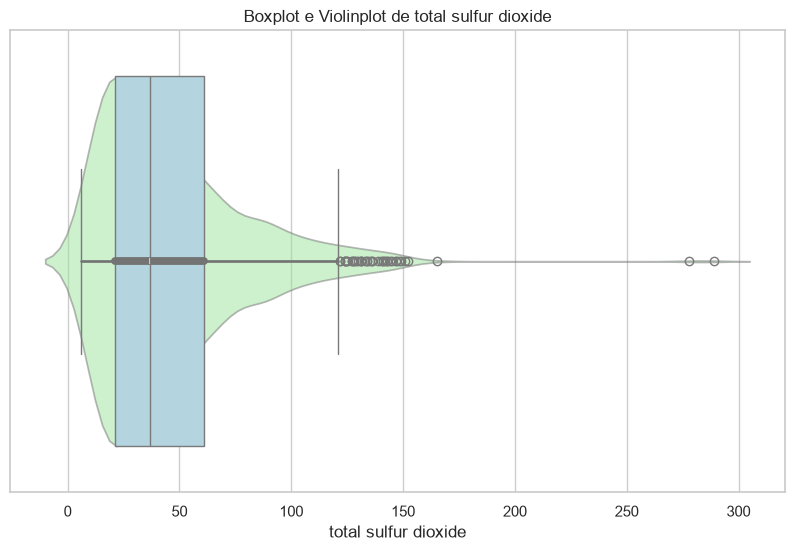

Outliers de total sulfur dioxide: 40 registros


,Id,total sulfur dioxide,quality
288,414,122.0000,5
491,693,122.0000,5
291,417,124.0000,5
278,400,124.0000,5
275,396,124.0000,5
61,88,125.0000,5
492,694,125.0000,5
514,723,127.0000,5
136,190,127.0000,5
106,155,128.0000,5


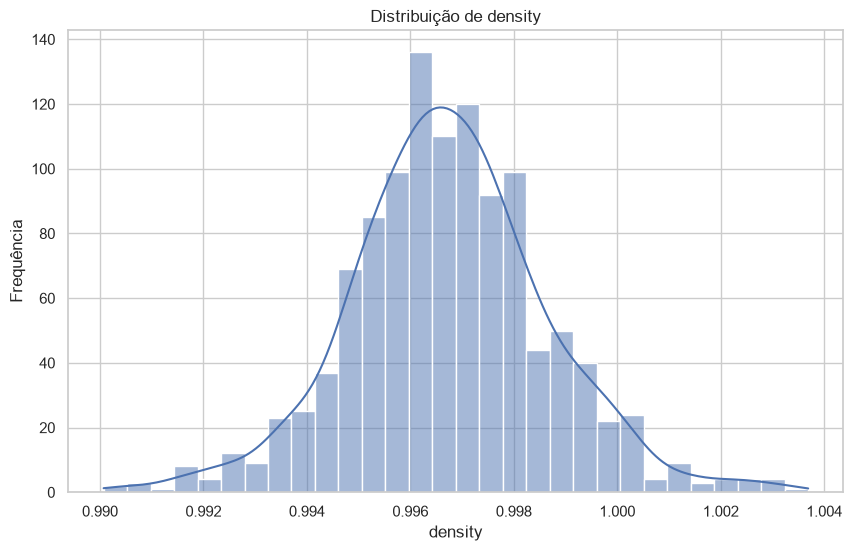

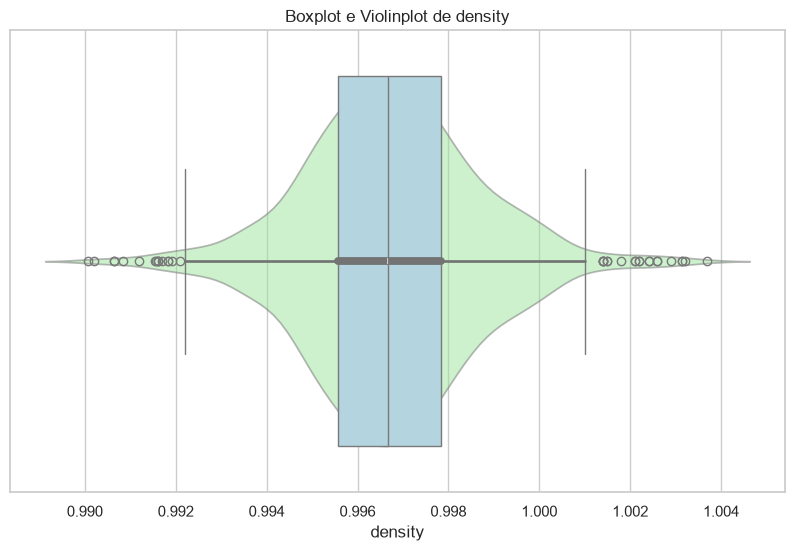

Outliers de density: 36 registros


,Id,density,quality
714,1018,0.9901,6
787,1114,0.9902,6
598,837,0.9906,7
597,836,0.9906,7
898,1270,0.9908,6
249,354,0.9912,6
589,821,0.9915,7
868,1228,0.9916,7
96,142,0.9916,6
98,144,0.9916,6


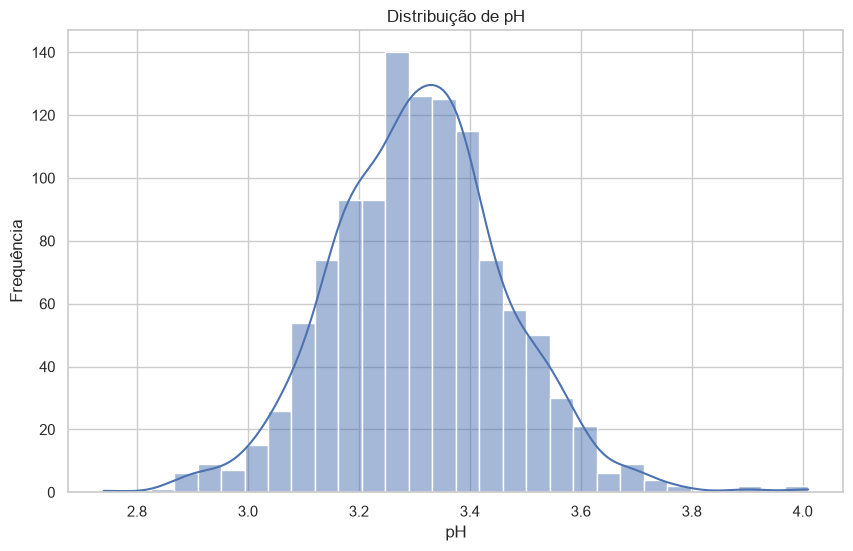

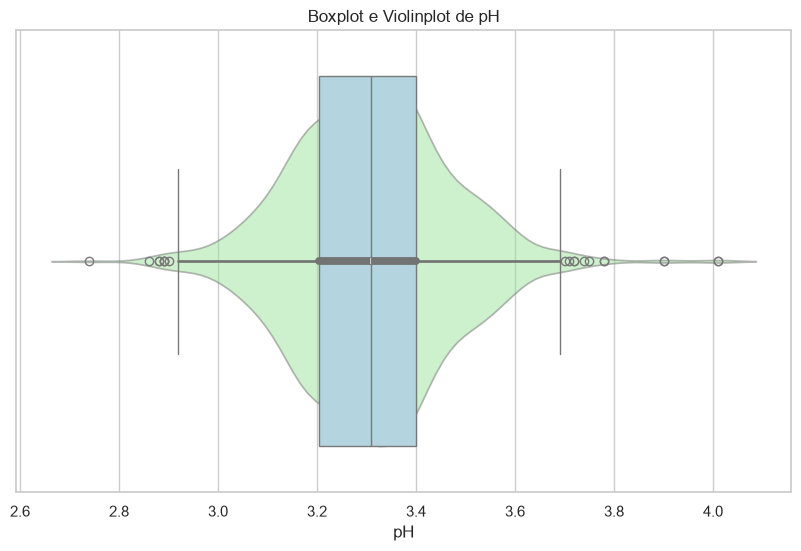

Outliers de pH: 20 registros


,Id,pH,quality
103,151,2.7400,4
388,544,2.8600,6
310,440,2.8800,8
1047,1470,2.8800,5
461,650,2.8900,5
466,656,2.8900,5
714,1018,2.8900,6
934,1319,2.9000,6
898,1270,3.7000,6
589,821,3.7100,7


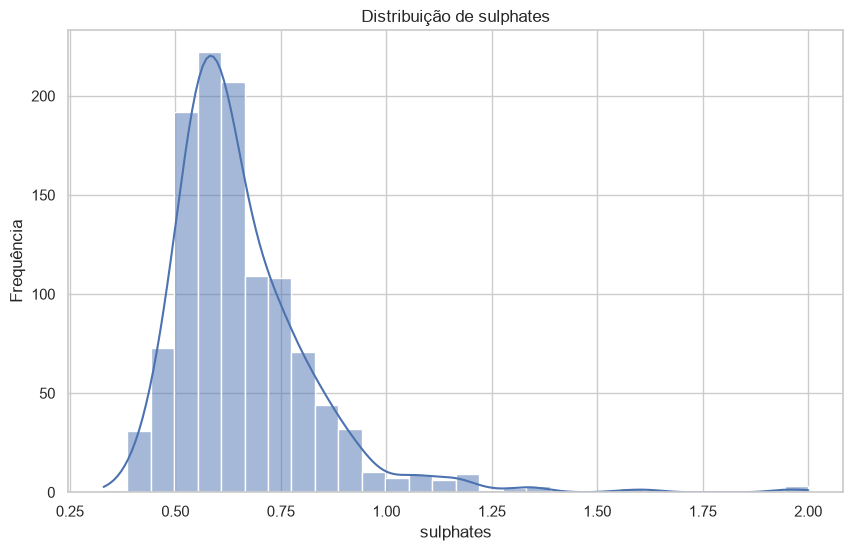

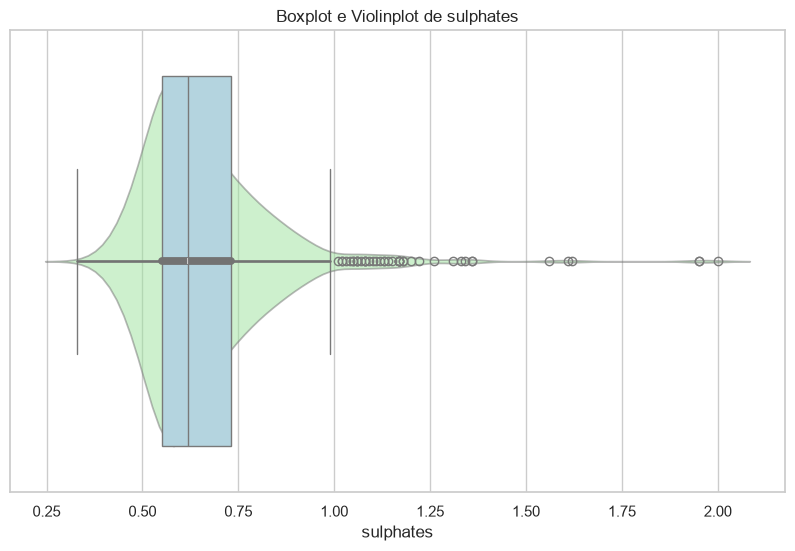

Outliers de sulphates: 43 registros


,Id,sulphates,quality
1000,1408,1.0100,7
359,506,1.0200,7
129,181,1.0200,5
974,1371,1.0300,6
264,372,1.0400,6
488,689,1.0500,5
357,504,1.0500,7
538,754,1.0600,6
341,483,1.0600,5
337,477,1.0600,6


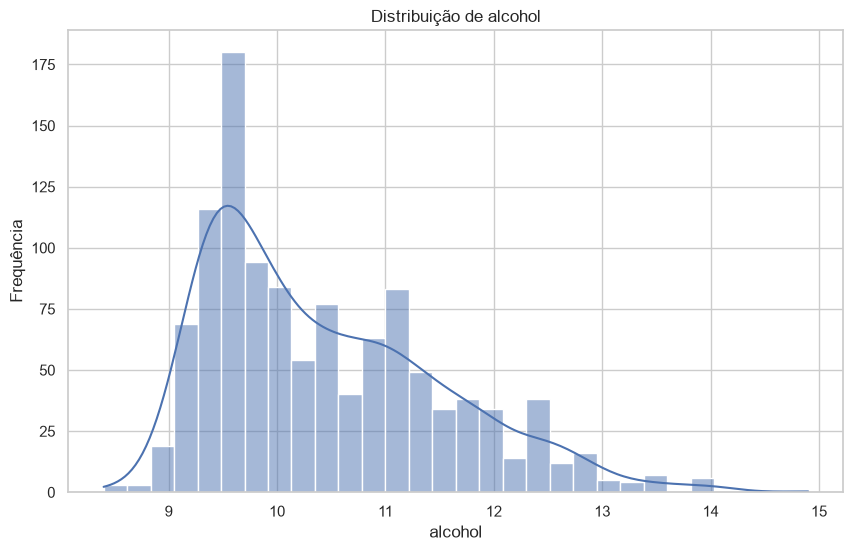

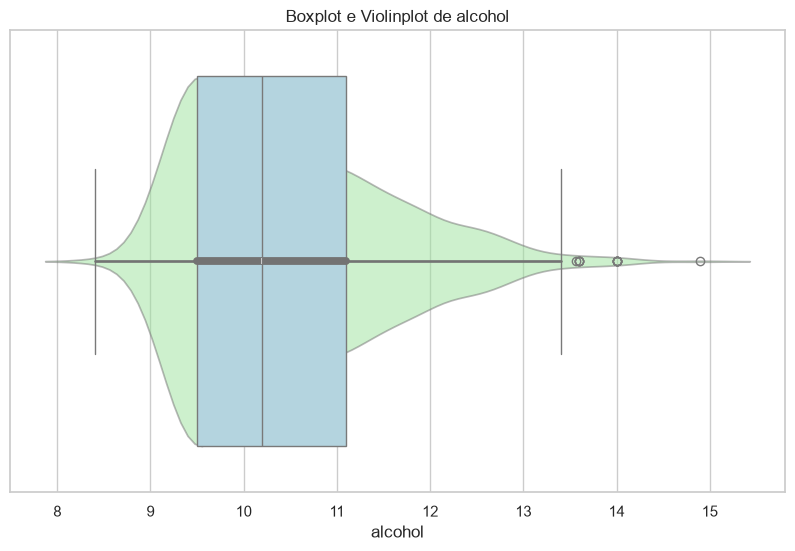

Outliers de alcohol: 12 registros


,Id,alcohol,quality
1052,1475,13.5667,7
787,1114,13.6000,6
799,1132,13.6000,7
868,1228,13.6000,7
1054,1477,13.6000,7
96,142,14.0000,6
98,144,14.0000,6
329,467,14.0000,6
419,588,14.0000,8
589,821,14.0000,7


In [34]:
# Calcula e imprime o resumo geral de outliers por variável
resumo_outlier = detalhe_ouliers()

print("Resumo de outliers por variável:")
display(
    resumo_outlier.sort_values(by="qtd_outliers", ascending=False).style.format({
        "q1": "{:.3f}",
        "q3": "{:.3f}",
        "iqr": "{:.3f}",
        "limite_inferior": "{:.3f}",
        "limite_superior": "{:.3f}",
        "pct_outliers": "{:.2f}%"
    })
)

num_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["quality", "Id"]
]

print("Análise detalhada de outliers por variável:")

for col in num_cols:
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

    sns.boxplot(x=df[col], color="lightblue")
    sns.violinplot(x=df[col], color="lightgreen", alpha=0.5)
    plt.title(f"Boxplot e Violinplot de {col}")
    plt.xlabel(col)
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_col = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"Outliers de {col}: {outliers_col.shape[0]} registros")
    if outliers_col.empty:
        print("Nenhum outlier encontrado para esta variável.")
    else:
        colunas_exibir = [c for c in ["Id", col, "quality"] if c in outliers_col.columns]
        display(outliers_col[colunas_exibir].sort_values(by=col))

Para complementar a análise visual dos boxplots e violin, calculei e detalhei a quantidade de outliers por variável, usando o método do intervalo interquartil (IQR). Valores abaixo de Q1 - 1,5 × IQR ou acima de Q3 + 1,5 × IQR são classificados como outliers.

A presença de outliers não implica remoção automática. No contexto deste projeto, os valores extremos representam características físico-químicas reais de determinados vinhos e, portanto, devem ser avaliados com cautela. Como o objetivo é classificação, esses pontos podem conter informação útil para diferenciar vinhos de alta qualidade.

#### Distribuição das variáveis em uma só Figura

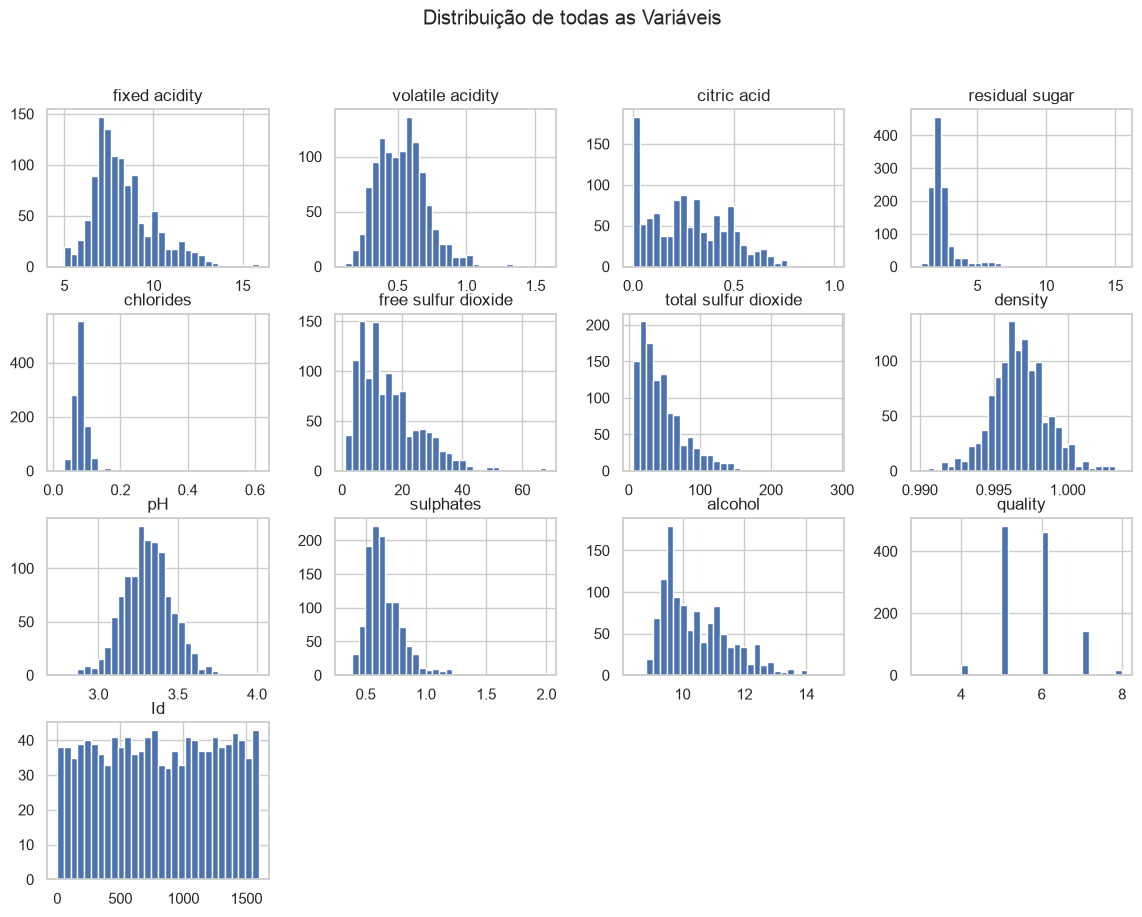

In [16]:
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribuição de todas as Variáveis")
plt.show()

#### Correlacão das Variáveis com `quality`

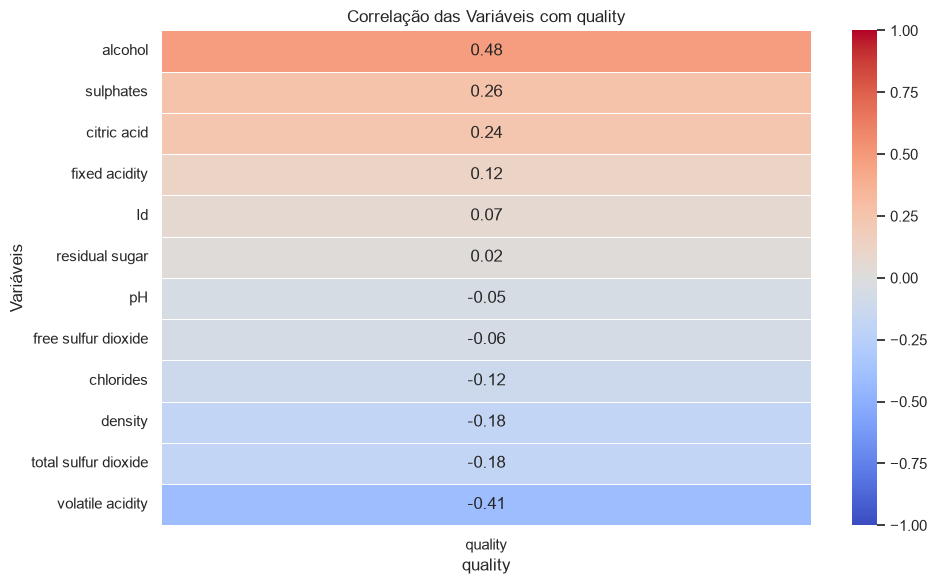

In [44]:
corr_quality = (
    df.corr(numeric_only=True)[["quality"]]
    .drop(index="quality")
    .sort_values(by="quality", ascending=False)
    .round(2)
)

fig, ax = plt.subplots()
sns.heatmap(
    data=corr_quality,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=ax
)
ax.set_title("Correlação das Variáveis com quality")
ax.set_xlabel("quality")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

---

## PRE-PROCESSAMENTO E DEFINICAO DO ALVO

Classificando a variável Target `quality` em
**classificacao binaria**:

- **Alta qualidade (classe 1):** `quality >= 7`
- **Baixa/Media qualidade (classe 0):** `quality < 7`

Removendo linhas com perfil físico-químico identico (duplicatas) antes de realizar o split, e descartando a variável `Id`. Manter registros idênticos poderia distribuir a mesma
amostra entre treino e teste, podendo causar **data leakage** e inflar as métricas.


In [35]:
# Remocao do Id
df_model = df.drop(columns=[c for c in ["Id"] if c in df.columns]).copy()

#Removendo as duplicatas
n_dup = df_model.duplicated().sum()
df_model = df_model.drop_duplicates().reset_index(drop=True)

print(f"Duplicatas removidas: {n_dup}")
print(f"Shape final para modelagem: {df_model.shape}")

Duplicatas removidas: 125
Shape final para modelagem: (1018, 12)


#### Criando o alvo binário -> Variável Target `quality`

In [57]:
quality_threshold = 7
y = (df_model["quality"] >= quality_threshold)
X = df_model.drop(columns=["quality"])
feature_names = X.columns.tolist()

print("Distribuicao do alvo binario:")
print(y.value_counts().rename({0: "Baixa/Media (0)", 1: "Alta (1)"}))
print(f"\nTaxa de vinhos de alta qualidade: {y.mean():.1%}")

Distribuicao do alvo binario:
quality
Baixa/Media (0)    881
Alta (1)           137
Name: count, dtype: int64

Taxa de vinhos de alta qualidade: 13.5%


As Classes estão desbalanceadas: Mais vinhos classificados como de Baixa/Media qualidade do que vinhos classificados como Alta Qualidade. 

Visualização gráfica abaixo:

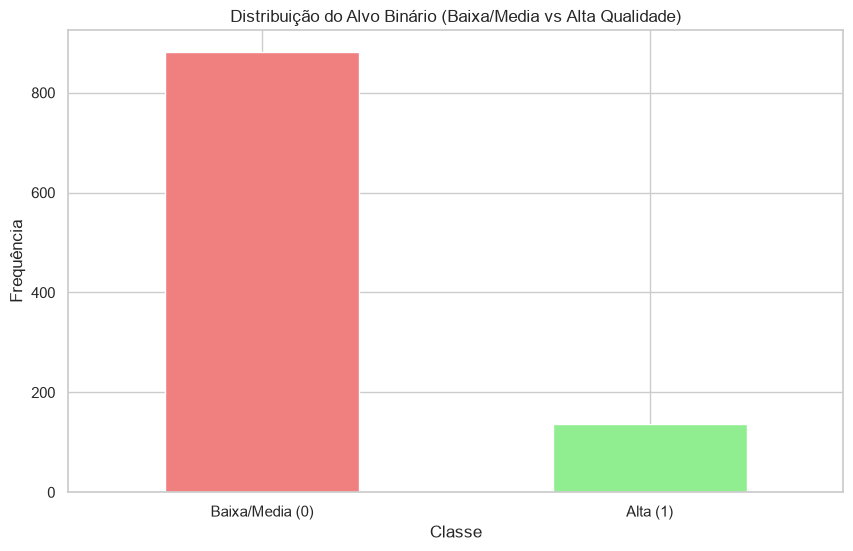

In [58]:
dist_alvo = y.value_counts().sort_index()
dist_alvo.index = ["Baixa/Media (0)", "Alta (1)"]

dist_alvo.plot(kind="bar", color=["lightcoral", "lightgreen"])
plt.title("Distribuição do Alvo Binário (Baixa/Media vs Alta Qualidade)")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

### Separacao treino/teste (estratificada)

`stratify=y` para preservar a proporcao de classes em ambos os conjuntos e `random_state=42` para reprodutibilidade.

In [59]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} alta qualidade)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} alta qualidade)")

Treino: 814 amostras (13.5% alta qualidade)
Teste:  204 amostras (13.2% alta qualidade)
